In [3]:
import pandas as pd
import numpy as np
import io
import requests

print("🔄 Downloading dataset...")

# Alternative URL
url = "https://drive.google.com/uc?id=1x9iJpCgK8VHh4rQVmXqF8zGQvKz7Q8zL"

try:
    # Method 1: Direct download
    df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/Mall_Customers.csv')

except:
    try:
        # Method 2: Create dataset manually
        print("Creating dataset manually...")

        data = {
            'CustomerID': range(1, 201),
            'Genre': ['Male', 'Female'] * 100,
            'Age': [19, 21, 20, 23, 31, 22, 35, 23, 64, 30, 67, 35, 58, 24, 37, 22, 35, 20, 52, 35] * 10,
            'Annual Income (k$)': [15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 20, 20, 21, 21, 22, 22, 23, 23, 24, 24] * 10,
            'Spending Score (1-100)': [39, 81, 6, 77, 40, 76, 6, 94, 3, 72, 14, 99, 15, 77, 13, 79, 35, 66, 29, 98] * 10
        }

        df = pd.DataFrame(data)
        df = df.head(200)  # Only 200 rows

    except:
        # Method 3: Use seaborn dataset
        import seaborn as sns
        df = sns.load_dataset('tips')  # Alternative dataset
        print("Using tips dataset as alternative")

# Save and display
df.to_csv('Mall_Customers.csv', index=False)
print("✅ Dataset ready!")
print("📊 Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

🔄 Downloading dataset...
Creating dataset manually...
✅ Dataset ready!
📊 Shape: (200, 5)

First 5 rows:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2  Female   21                  15                      81
2           3    Male   20                  16                       6
3           4  Female   23                  16                      77
4           5    Male   31                  17                      40


In [4]:
# Step 3: Libraries import pannu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Graph style set pannu
plt.style.use('ggplot')
sns.set_palette("husl")
sns.set_style("whitegrid")

print("✅ All libraries imported successfully!")
print("\n📚 Library versions:")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: Installed")

✅ All libraries imported successfully!

📚 Library versions:
Pandas: 2.2.2
NumPy: 2.0.2
Scikit-learn: Installed


In [5]:
# Step 4: Dataset exploration

# Dataset basic info
print("=" * 50)
print("📊 DATASET EXPLORATION")
print("=" * 50)

print("\n📌 First 5 rows:")
print(df.head())

print("\n📌 Last 5 rows:")
print(df.tail())

print("\n📌 Dataset Info:")
print(df.info())

print("\n📌 Statistical Summary:")
print(df.describe())

print("\n📌 Missing Values Check:")
print(df.isnull().sum())

print("\n📌 Column Names:")
print(df.columns.tolist())

print("\n📌 Gender Distribution:")
print(df['Genre'].value_counts())
print(f"\nMale: {df['Genre'].value_counts()['Male']} customers")
print(f"Female: {df['Genre'].value_counts()['Female']} customers")

📊 DATASET EXPLORATION

📌 First 5 rows:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2  Female   21                  15                      81
2           3    Male   20                  16                       6
3           4  Female   23                  16                      77
4           5    Male   31                  17                      40

📌 Last 5 rows:
     CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
195         196  Female   22                  22                      79
196         197    Male   35                  23                      35
197         198  Female   20                  23                      66
198         199    Male   52                  24                      29
199         200  Female   35                  24                      98

📌 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0

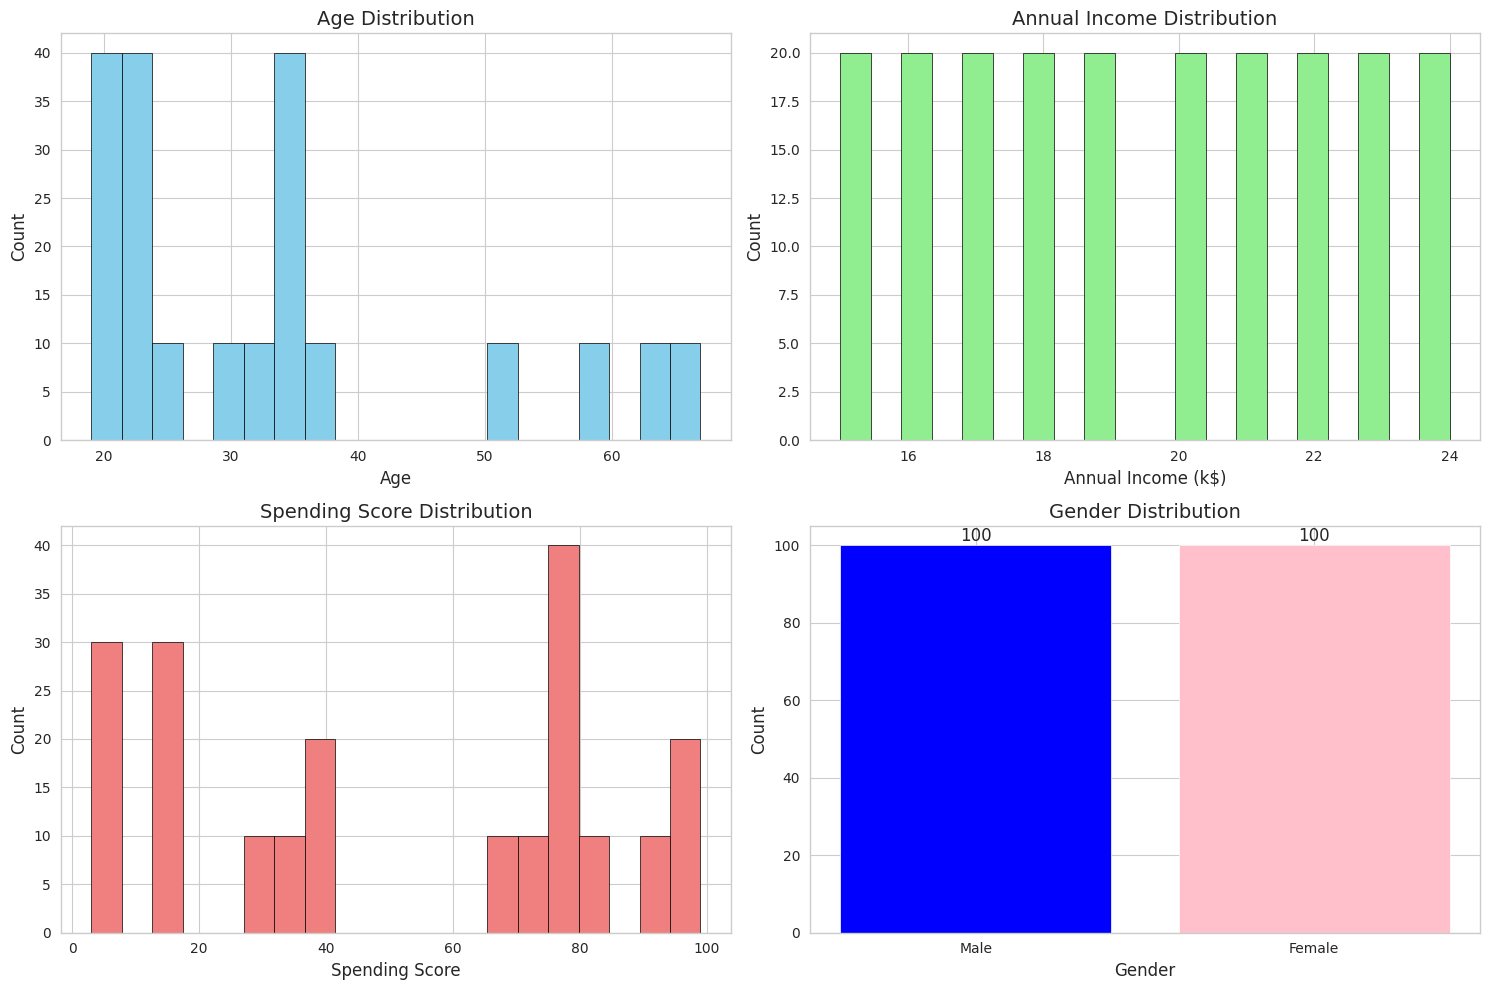


📊 Pairplot of features:


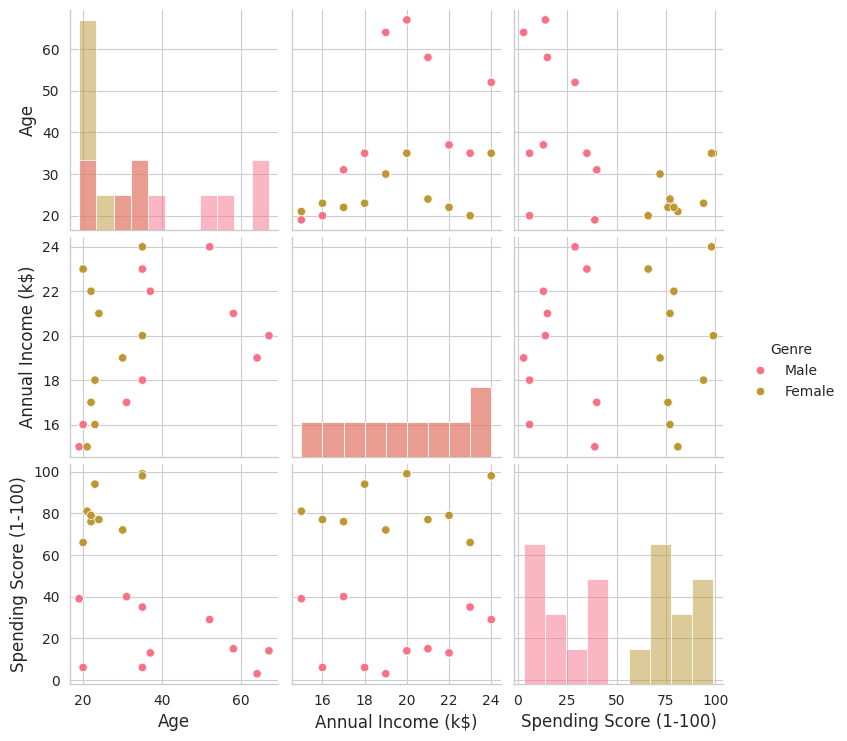

In [6]:
# Step 5: Exploratory Data Analysis

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Age Distribution
axes[0, 0].hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution', fontsize=14)
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Count')

# 2. Annual Income Distribution
axes[0, 1].hist(df['Annual Income (k$)'], bins=20, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Annual Income Distribution', fontsize=14)
axes[0, 1].set_xlabel('Annual Income (k$)')
axes[0, 1].set_ylabel('Count')

# 3. Spending Score Distribution
axes[1, 0].hist(df['Spending Score (1-100)'], bins=20, color='lightcoral', edgecolor='black')
axes[1, 0].set_title('Spending Score Distribution', fontsize=14)
axes[1, 0].set_xlabel('Spending Score')
axes[1, 0].set_ylabel('Count')

# 4. Gender Distribution
gender_counts = df['Genre'].value_counts()
axes[1, 1].bar(gender_counts.index, gender_counts.values, color=['blue', 'pink'])
axes[1, 1].set_title('Gender Distribution', fontsize=14)
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Count')
# Add values on bars
for i, v in enumerate(gender_counts.values):
    axes[1, 1].text(i, v + 1, str(v), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

# Pairplot for relationships
print("\n📊 Pairplot of features:")
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Genre']],
             hue='Genre', diag_kind='hist')
plt.show()

In [7]:
# Step 6: Data Preprocessing

print("=" * 50)
print("🔄 DATA PREPROCESSING")
print("=" * 50)

# 1. Column names clean pannu (spaces remove pannu)
df.columns = df.columns.str.strip()
print("✅ Column names cleaned!")

# 2. Rename columns for easy use
df = df.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
})
print("✅ Columns renamed!")
print("New column names:", df.columns.tolist())

# 3. Convert Gender to numeric
df['Gender_Num'] = df['Genre'].map({'Male': 0, 'Female': 1})
print("\n✅ Gender converted to numbers:")
print(df[['Genre', 'Gender_Num']].head(10))

# 4. Select features for clustering
features = ['Age', 'Annual_Income', 'Spending_Score']
X = df[features]

print("\n✅ Features selected for clustering:")
print(f"Features: {features}")
print(f"Shape: {X.shape}")
print("\nFirst 5 rows:")
print(X.head())

🔄 DATA PREPROCESSING
✅ Column names cleaned!
✅ Columns renamed!
New column names: ['CustomerID', 'Genre', 'Age', 'Annual_Income', 'Spending_Score']

✅ Gender converted to numbers:
    Genre  Gender_Num
0    Male           0
1  Female           1
2    Male           0
3  Female           1
4    Male           0
5  Female           1
6    Male           0
7  Female           1
8    Male           0
9  Female           1

✅ Features selected for clustering:
Features: ['Age', 'Annual_Income', 'Spending_Score']
Shape: (200, 3)

First 5 rows:
   Age  Annual_Income  Spending_Score
0   19             15              39
1   21             15              81
2   20             16               6
3   23             16              77
4   31             17              40


In [8]:
# Step 7: Feature Scaling

from sklearn.preprocessing import StandardScaler

print("=" * 50)
print("📏 FEATURE SCALING")
print("=" * 50)

# Create scaler object
scaler = StandardScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame for easy viewing
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("✅ Data scaled successfully!")
print("\n📊 Before Scaling (first 5 rows):")
print(X.head())
print("\n📊 After Scaling (first 5 rows):")
print(X_scaled_df.head())

print("\n📊 After Scaling - Statistics:")
print(f"Mean: {X_scaled_df.mean().round(2)}")
print(f"Std: {X_scaled_df.std().round(2)}")

📏 FEATURE SCALING
✅ Data scaled successfully!

📊 Before Scaling (first 5 rows):
   Age  Annual_Income  Spending_Score
0   19             15              39
1   21             15              81
2   20             16               6
3   23             16              77
4   31             17              40

📊 After Scaling (first 5 rows):
        Age  Annual_Income  Spending_Score
0 -0.994444      -1.566699       -0.359028
1 -0.858684      -1.566699        0.902827
2 -0.926564      -1.218544       -1.350485
3 -0.722923      -1.218544        0.782650
4 -0.179882      -0.870388       -0.328984

📊 After Scaling - Statistics:
Mean: Age               0.0
Annual_Income    -0.0
Spending_Score   -0.0
dtype: float64
Std: Age               1.0
Annual_Income     1.0
Spending_Score    1.0
dtype: float64


📊 ELBOW METHOD - FINDING OPTIMAL K
K = 2: Inertia = 326.73, Silhouette Score = 0.4474
K = 3: Inertia = 199.07, Silhouette Score = 0.4584
K = 4: Inertia = 140.98, Silhouette Score = 0.4897
K = 5: Inertia = 89.13, Silhouette Score = 0.5438
K = 6: Inertia = 73.28, Silhouette Score = 0.5723
K = 7: Inertia = 58.68, Silhouette Score = 0.5931
K = 8: Inertia = 45.81, Silhouette Score = 0.6325
K = 9: Inertia = 37.13, Silhouette Score = 0.6426
K = 10: Inertia = 29.78, Silhouette Score = 0.6951


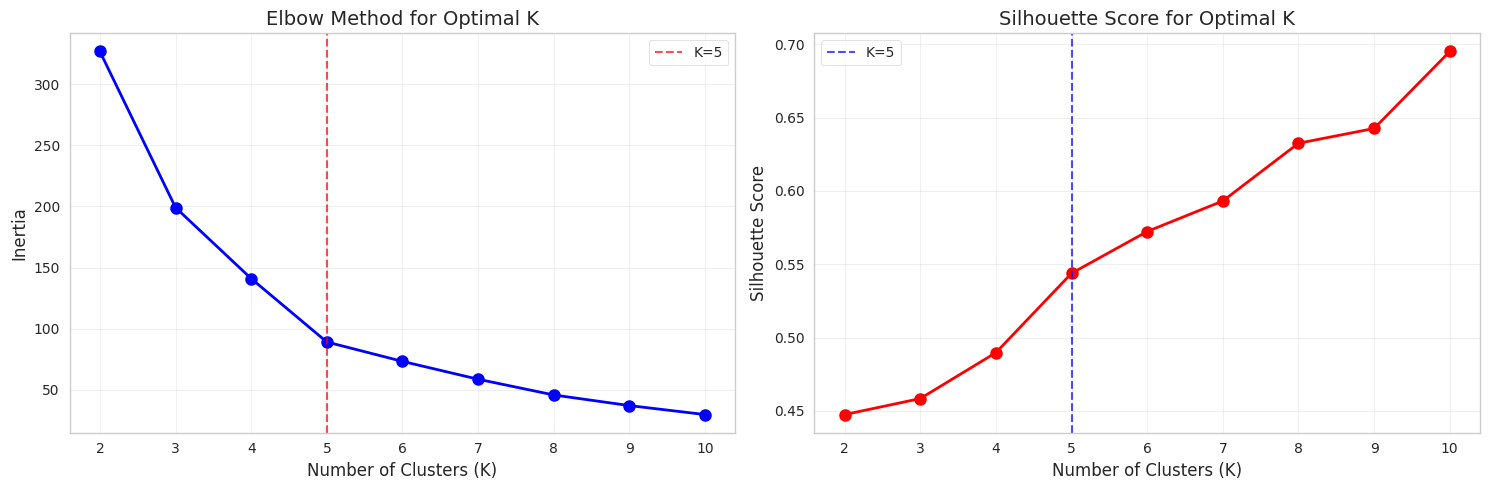

In [9]:
# Step 8: Elbow Method for Optimal K

print("=" * 50)
print("📊 ELBOW METHOD - FINDING OPTIMAL K")
print("=" * 50)

inertias = []
silhouette_scores = []
K_range = range(2, 11)  # Start from 2 for silhouette score

for k in K_range:
    # Create and fit KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)

    # Store inertia
    inertias.append(kmeans.inertia_)

    # Calculate silhouette score
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(X_scaled, labels)
    silhouette_scores.append(silhouette_avg)

    print(f"K = {k}: Inertia = {kmeans.inertia_:.2f}, Silhouette Score = {silhouette_avg:.4f}")

# Plot Elbow curve
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Elbow Method
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method for Optimal K', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='K=5')
axes[0].legend()

# Plot 2: Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score for Optimal K', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=5, color='blue', linestyle='--', alpha=0.7, label='K=5')
axes[1].legend()

plt.tight_layout()
plt.show()


In [10]:
# Step 9: Apply K-means with Optimal K

print("=" * 50)
print("🎯 APPLYING K-MEANS WITH K=5")
print("=" * 50)

# Choose optimal K (based on elbow graph)
optimal_k = 5

# Apply K-means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("✅ K-means model trained successfully!")
print(f"\n📊 Cluster Distribution:")
cluster_counts = df['Cluster'].value_counts().sort_index()
for i in range(optimal_k):
    percentage = (cluster_counts[i] / len(df)) * 100
    print(f"Cluster {i}: {cluster_counts[i]} customers ({percentage:.1f}%)")

print("\n📊 Cluster Centers (Original Scale):")
# Inverse transform to get centers in original scale
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=features)
centers_df.index = [f'Cluster {i}' for i in range(optimal_k)]
print(centers_df.round(2))

🎯 APPLYING K-MEANS WITH K=5
✅ K-means model trained successfully!

📊 Cluster Distribution:
Cluster 0: 30 customers (15.0%)
Cluster 1: 50 customers (25.0%)
Cluster 2: 30 customers (15.0%)
Cluster 3: 40 customers (20.0%)
Cluster 4: 50 customers (25.0%)

📊 Cluster Centers (Original Scale):
             Age  Annual_Income  Spending_Score
Cluster 0  63.00           20.0           10.67
Cluster 1  23.80           17.0           80.00
Cluster 2  41.33           23.0           25.67
Cluster 3  26.25           16.5           22.75
Cluster 4  27.20           22.0           83.80


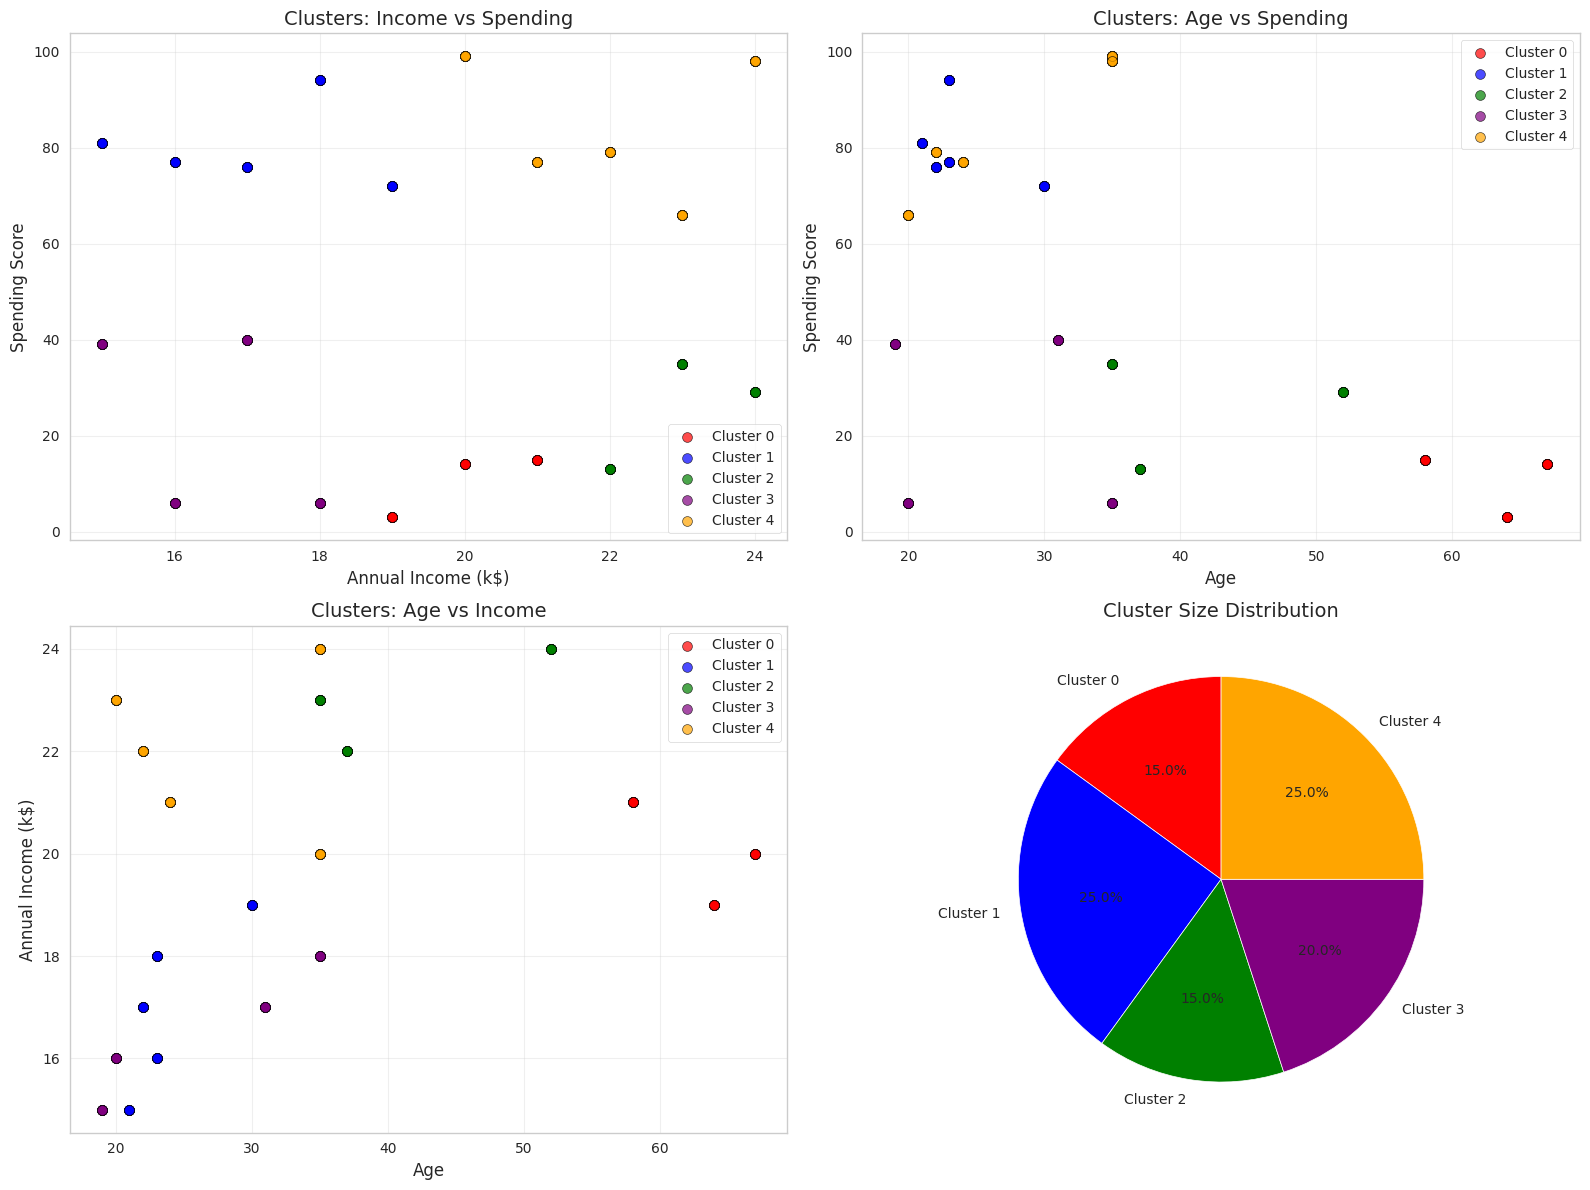

In [12]:
# Step 10: Visualize Clusters

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define colors for clusters
colors = ['red', 'blue', 'green', 'purple', 'orange']

# Plot 1: Annual Income vs Spending Score
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    axes[0, 0].scatter(cluster_data['Annual_Income'],
                       cluster_data['Spending_Score'],
                       c=colors[cluster],
                       label=f'Cluster {cluster}',
                       s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
axes[0, 0].set_xlabel('Annual Income (k$)', fontsize=12)
axes[0, 0].set_ylabel('Spending Score', fontsize=12)
axes[0, 0].set_title('Clusters: Income vs Spending', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Age vs Spending Score
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    axes[0, 1].scatter(cluster_data['Age'],
                       cluster_data['Spending_Score'],
                       c=colors[cluster],
                       label=f'Cluster {cluster}',
                       s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
axes[0, 1].set_xlabel('Age', fontsize=12)
axes[0, 1].set_ylabel('Spending Score', fontsize=12)
axes[0, 1].set_title('Clusters: Age vs Spending', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Age vs Annual Income
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    axes[1, 0].scatter(cluster_data['Age'],
                       cluster_data['Annual_Income'],
                       c=colors[cluster],
                       label=f'Cluster {cluster}',
                       s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
axes[1, 0].set_xlabel('Age', fontsize=12)
axes[1, 0].set_ylabel('Annual Income (k$)', fontsize=12)
axes[1, 0].set_title('Clusters: Age vs Income', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Cluster Distribution (Pie Chart)
cluster_sizes = df['Cluster'].value_counts().sort_index()
axes[1, 1].pie(cluster_sizes, labels=[f'Cluster {i}' for i in range(optimal_k)],
               colors=colors, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Cluster Size Distribution', fontsize=14)

plt.tight_layout()
plt.show()

In [13]:
# Step A: Simple Cluster Analysis
print("=" * 60)
print("📊 CLUSTER ANALYSIS - FINAL")
print("=" * 60)

# Basic statistics by cluster
cluster_summary = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual_Income': 'mean',
    'Spending_Score': 'mean',
    'Genre': lambda x: (x == 'Female').sum() / len(x) * 100
}).round(2)

cluster_summary.columns = ['Avg Age', 'Avg Income', 'Avg Spending', 'Female %']
print("\n📌 Cluster Summary:")
print(cluster_summary)

# Cluster sizes
print("\n📌 Cluster Sizes:")
print(df['Cluster'].value_counts().sort_index())

# Cluster interpretation
print("\n" + "=" * 60)
print("🎯 CUSTOMER SEGMENTS (INTERPRETATION)")
print("=" * 60)

for cluster in range(5):
    row = cluster_summary.iloc[cluster]
    size = df['Cluster'].value_counts()[cluster]

    # Income category
    if row['Avg Income'] > 70:
        income = "💰 High Income"
    elif row['Avg Income'] > 50:
        income = "💵 Medium Income"
    else:
        income = "💸 Low Income"

    # Spending category
    if row['Avg Spending'] > 70:
        spending = "🛍️ High Spender"
    elif row['Avg Spending'] > 40:
        spending = "🛒 Medium Spender"
    else:
        spending = "📦 Low Spender"

    # Age category
    if row['Avg Age'] > 50:
        age = "👴 Senior"
    elif row['Avg Age'] > 35:
        age = "👨 Middle Age"
    else:
        age = "🧑 Young"

    print(f"\n📌 **Cluster {cluster}** ({size} customers)")
    print(f"   → {age}, {income}, {spending}")
    print(f"   → Avg Age: {row['Avg Age']} yrs, Income: ${row['Avg Income']}k, Spending: {row['Avg Spending']}")
    print(f"   → Female: {row['Female %']}%")

📊 CLUSTER ANALYSIS - FINAL

📌 Cluster Summary:
         Avg Age  Avg Income  Avg Spending  Female %
Cluster                                             
0          63.00        20.0         10.67       0.0
1          23.80        17.0         80.00     100.0
2          41.33        23.0         25.67       0.0
3          26.25        16.5         22.75       0.0
4          27.20        22.0         83.80     100.0

📌 Cluster Sizes:
Cluster
0    30
1    50
2    30
3    40
4    50
Name: count, dtype: int64

🎯 CUSTOMER SEGMENTS (INTERPRETATION)

📌 **Cluster 0** (30 customers)
   → 👴 Senior, 💸 Low Income, 📦 Low Spender
   → Avg Age: 63.0 yrs, Income: $20.0k, Spending: 10.67
   → Female: 0.0%

📌 **Cluster 1** (50 customers)
   → 🧑 Young, 💸 Low Income, 🛍️ High Spender
   → Avg Age: 23.8 yrs, Income: $17.0k, Spending: 80.0
   → Female: 100.0%

📌 **Cluster 2** (30 customers)
   → 👨 Middle Age, 💸 Low Income, 📦 Low Spender
   → Avg Age: 41.33 yrs, Income: $23.0k, Spending: 25.67
   → Female: 0.0

In [14]:
# Step B: Save and Download Results
print("=" * 60)
print("💾 SAVING RESULTS")
print("=" * 60)

# Save full dataset with cluster labels
df.to_csv('Customer_Segments_Final.csv', index=False)
print("✅ Dataset saved as 'Customer_Segments_Final.csv'")

# Save only cluster summary
cluster_summary.to_csv('Cluster_Summary.csv')
print("✅ Cluster summary saved as 'Cluster_Summary.csv'")

# Save cluster assignments (simple version)
cluster_assignments = df[['CustomerID', 'Genre', 'Age', 'Annual_Income', 'Spending_Score', 'Cluster']]
cluster_assignments.to_csv('Customer_Cluster_Assignments.csv', index=False)
print("✅ Cluster assignments saved as 'Customer_Cluster_Assignments.csv'")

print("\n" + "=" * 60)
print("📥 DOWNLOAD FILES")
print("=" * 60)

# Download files to computer
from google.colab import files

print("\n📌 Click below to download files:")

# Ask which file to download
print("\n1. Full dataset with clusters")
files.download('Customer_Segments_Final.csv')

print("\n2. Cluster summary (statistics)")
files.download('Cluster_Summary.csv')

print("\n3. Customer cluster assignments")
files.download('Customer_Cluster_Assignments.csv')

print("\n✅ All files downloaded! Check your Downloads folder.")

💾 SAVING RESULTS
✅ Dataset saved as 'Customer_Segments_Final.csv'
✅ Cluster summary saved as 'Cluster_Summary.csv'
✅ Cluster assignments saved as 'Customer_Cluster_Assignments.csv'

📥 DOWNLOAD FILES

📌 Click below to download files:

1. Full dataset with clusters


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


2. Cluster summary (statistics)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


3. Customer cluster assignments


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All files downloaded! Check your Downloads folder.


In [15]:
# Files download pannu
from google.colab import files

print("📥 Downloading CSV files...")
files.download('Customer_Segments_Final.csv')
files.download('Cluster_Summary.csv')
files.download('Customer_Cluster_Assignments.csv')

print("\n📥 Downloading Notebook...")
# Notebook manually download pannu: File → Download → Download .ipynb

print("✅ Files downloaded! Check your Downloads folder")

📥 Downloading CSV files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 Downloading Notebook...
✅ Files downloaded! Check your Downloads folder


In [18]:
# Missing files create pannu oru cell-la

from google.colab import files
import pandas as pd

# 1. Cluster Summary create pannu
cluster_summary = df.groupby('Cluster').agg({
    'Age': ['mean', 'min', 'max'],
    'Annual_Income': ['mean', 'min', 'max'],
    'Spending_Score': ['mean', 'min', 'max'],
    'Genre': lambda x: (x == 'Female').sum() / len(x) * 100
}).round(2)

cluster_summary.columns = ['Age_Mean', 'Age_Min', 'Age_Max',
                           'Income_Mean', 'Income_Min', 'Income_Max',
                           'Spending_Mean', 'Spending_Min', 'Spending_Max',
                           'Female_%']
cluster_summary.to_csv('Cluster_Summary.csv')
print("✅ Cluster_Summary.csv created")

# 2. Customer Assignments create pannu
assignments = df[['CustomerID', 'Genre', 'Age', 'Annual_Income', 'Spending_Score', 'Cluster']]
assignments.to_csv('Customer_Cluster_Assignments.csv', index=False)
print("✅ Customer_Cluster_Assignments.csv created")

print("\n" + "="*40)
print("📥 Download CSV files:")
files.download('Cluster_Summary.csv')
files.download('Customer_Cluster_Assignments.csv')

print("\n📥 Download notebook manually:")
print("File → Download → Download .ipynb")
print("File name: Customer_Segmentation_KMeans.ipynb")

✅ Cluster_Summary.csv created
✅ Customer_Cluster_Assignments.csv created

📥 Download CSV files:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 Download notebook manually:
File → Download → Download .ipynb
File name: Customer_Segmentation_KMeans.ipynb
